# Exploratory Data Analysis - Global AI & Data Jobs Salary Dataset

## Objective

The purpose of this exploratory data analysis is to understand the structure, quality, distributions and relationships within the Global AI & Data Jobs Salary Dataset.

The primary target variable is `salary_usd`. The analysis will investigate how salary varies with factors such as experience, job role, country, AI specialisation, education, industry and other employment-related characteristics.

| Section | Purpose |
|---|---|
| **1. Set Project Root and Load Configuration** | Set up reusable project-relative paths and load configuration using Hydra. |
| **2. Load Dataset and Preview** | Load the dataset and verify that it has been read correctly. |
| **3. Dataset Structure** | Understand the dataset dimensions, data types, and meaning of each variable. |
| **4. Data Quality Assessment** | Identify missing values, duplicates, inconsistent categories, unusual cardinality, and invalid numerical values. |
| **5. Univariate Analysis** | Examine the distribution, skewness, and potential outliers of individual variables. |
| **6. Bivariate Analysis** | Examine relationships between individual features and `salary_usd`, as well as relationships between numerical predictors. |
| **7. Multivariate Analysis** | Examine salary patterns when multiple important variables are considered together. |
| **8. Key EDA Findings** | Summarise the main insights and identify considerations for later preprocessing and modelling. |

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from hydra import compose, initialize

## 1. Set Project Root and Load Configuration

The project root directory is identified so that file paths can be resolved consistently from the main `mlops-assignment` folder.

`PROJECT_ROOT = Path.cwd().parents[1]`

Since the notebook is located inside `darren/notebooks/`, `Path.cwd()` returns the full path to the current notebook folder, for example: `C:/Users/username/Documents/GitHub/mlops-assignment/darren/notebooks`. Using `.parents[1]` moves up two folder levels to the main `mlops-assignment` directory. This allows the same code to work even if different team members store the project in different locations on their computers. 

Next, Hydra is used to load the project configuration file. `initialize(version_base=None, config_path="../conf")` tells Hydra that the configuration files are located inside the `darren/conf/` folder.

`compose(config_name="config")` loads `config.yaml` into `cfg`.

Finally, `raw_data_path = PROJECT_ROOT / cfg.data.raw_path` combines the project root with the dataset path defined inside `config.yaml`. This avoids hard-coding a specific user's full file path and allows file paths to be managed centrally through the configuration file.

In [2]:
# Project root: .../mlops-assignment
PROJECT_ROOT = Path.cwd().parents[1]

with initialize(version_base=None, config_path="../conf"):
    cfg = compose(config_name="config")
    
raw_data_path = PROJECT_ROOT / cfg.data.raw_path

## 2. Load Dataset and Preview

The raw dataset is loaded using the file path obtained from the Hydra configuration. The first few records are displayed to verify that the dataset has been loaded correctly.

In [3]:
df = pd.read_csv(raw_data_path)

df.head()

,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24,82,47,64,52,69,17,21,0.87,72


## 3. Dataset Structure

The dataset contains **90,000 records and 35 variables**.

Among the 35 variables:
- **27 are numerical variables**, consisting of 18 integer (`int64`) and 9 decimal (`float64`) columns.
- **8 are categorical variables** stored as `object`, including `country`, `job_role`, `ai_specialization`, `experience_level`, `education_required`, `industry`, `company_size`, and `work_mode`.

The `id` column appears to serve as a unique record identifier rather than an explanatory feature and will be examined further before modelling.

All columns currently contain 90,000 non-null values.

The dataset contains job, salary, company, economic, and career-related variables. The following data dictionary describes the meaning of each feature based on the Kaggle dataset documentation (https://www.kaggle.com/datasets/mohankrishnathalla/global-ai-and-data-jobs-salary-dataset/data).

| Column | Description |
|---|---|
| `id` | Unique identifier for each job record. |
| `country` | Country where the job position is located. |
| `job_role` | Primary job title or role category, such as Data Scientist, ML Engineer, or Software Engineer. |
| `ai_specialization` | Specific AI or technical specialization area associated with the role. |
| `experience_level` | Seniority level of the position, such as Entry, Mid, Senior, Lead, or Executive. |
| `experience_years` | Required or typical years of professional experience for the role. |
| `salary_usd` | Estimated annual base salary in USD. |
| `bonus_usd` | Estimated annual bonus or additional compensation in USD. |
| `education_required` | Minimum education qualification required for the role. |
| `industry` | Industry sector of the hiring company. |
| `company_size` | Company size category based on employee count. |
| `interview_rounds` | Typical number of interview rounds in the hiring process. |
| `year` | Year when the job record is observed. |
| `work_mode` | Work arrangement type, such as Remote, Hybrid, or Onsite. |
| `weekly_hours` | Average expected working hours per week. |
| `company_rating` | Estimated company rating representing workplace reputation or employee feedback. |
| `job_openings` | Number of available openings for similar roles. |
| `hiring_difficulty_score` | Score indicating how difficult it is for companies to fill the role. |
| `layoff_risk` | Estimated probability or risk level of layoffs affecting the role. |
| `ai_adoption_score` | Score representing how strongly the company or industry adopts AI technologies. |
| `company_funding_billion` | Estimated company funding or valuation level in billions of USD. |
| `economic_index` | Economic condition indicator reflecting overall market strength. |
| `ai_maturity_years` | Estimated number of years the organisation has been actively using AI technologies. |
| `offer_acceptance_rate` | Percentage of job offers typically accepted by candidates. |
| `tax_rate_percent` | Estimated effective income tax rate percentage applicable to the salary. |
| `vacation_days` | Average number of annual paid vacation days. |
| `skill_demand_score` | Score representing market demand for the required skills. |
| `automation_risk` | Estimated likelihood that the role could be automated in the future. |
| `job_security_score` | Score representing long-term job stability and retention likelihood. |
| `career_growth_score` | Score indicating potential career advancement opportunities. |
| `work_life_balance_score` | Score estimating expected work-life balance quality. |
| `promotion_speed` | Estimated relative speed of promotions within the role or company. |
| `salary_percentile` | Salary percentile ranking compared to similar roles globally. |
| `cost_of_living_index` | Index representing relative cost of living in the job location. |
| `employee_satisfaction` | Estimated employee satisfaction level associated with similar roles. |

In [4]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print()
df.info()
print()
print(df.columns.tolist())

Number of rows: 90,000
Number of columns: 35

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       90000 non-null  int64  
 1   country                  90000 non-null  object 
 2   job_role                 90000 non-null  object 
 3   ai_specialization        90000 non-null  object 
 4   experience_level         90000 non-null  object 
 5   experience_years         90000 non-null  int64  
 6   salary_usd               90000 non-null  int64  
 7   bonus_usd                90000 non-null  int64  
 8   education_required       90000 non-null  object 
 9   industry                 90000 non-null  object 
 10  company_size             90000 non-null  object 
 11  interview_rounds         90000 non-null  int64  
 12  year                     90000 non-null  int64  
 13  work_mode                90000

## 4. Data Quality Assessment

Before performing further analysis, the dataset is checked for potential data quality issues that may affect the reliability of the analysis and subsequent machine learning model.

The following aspects are examined:

- Missing values
- Duplicate records
- Number of unique values in each column
- Consistency of categorical values
- Potential invalid or unrealistic numerical values

### 4.1 Missing Values

No missing values were found in any of the 35 variables. All 90,000 records contain complete values for every column.

Since there are no missing values, no missing-value imputation or removal is required.

In [5]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values

,Missing Count,Missing Percentage (%)
id,0,0.0
country,0,0.0
job_role,0,0.0
ai_specialization,0,0.0
experience_level,0,0.0
experience_years,0,0.0
salary_usd,0,0.0
bonus_usd,0,0.0
education_required,0,0.0
industry,0,0.0


### 4.2 Duplicate Records

No duplicated records were found after excluding the unique `id` column. This provides a stronger duplicate check because records with different IDs but otherwise identical values would still be detected.

This indicates that each of the 90,000 records is unique at the row level, so no duplicate rows need to be removed.

In [44]:
duplicate_without_id = df.drop(columns=["id"]).duplicated().sum()

print(f"Duplicate records excluding ID: {duplicate_without_id}")

Duplicate records excluding ID: 0


### 4.3 Unique Values

The number of unique values in each variable was examined to better understand the type and granularity of the features.

Several variables have low cardinality and can be treated as categorical features, such as `work_mode` (3 values), `experience_level` (4 values), `education_required` (5 values), `company_size` (5 values), `job_role` (8 values), `ai_specialization` (8 values), `industry` (10 values), and `country` (12 values).

The `id` column contains 90,000 unique values, which is equal to the total number of records. This indicates that it is a unique identifier for each record rather than a meaningful predictive feature. Which should be excluded out during modelling later.

Other variables such as `salary_usd`, `bonus_usd`, `hiring_difficulty_score`, and `economic_index` contain many unique values and behave more like continuous numerical variables.

In [7]:
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
}).sort_values("Unique Values")

unique_values

,Column,Unique Values
13,work_mode,3
4,experience_level,4
8,education_required,5
10,company_size,5
11,interview_rounds,6
12,year,7
2,job_role,8
3,ai_specialization,8
9,industry,10
1,country,12


### 4.4 Categorical Value Consistency

The categorical variables were examined to identify inconsistent labels, spelling differences, or duplicated categories.

No obvious inconsistencies were found across the categorical variables. For example, values such as `Remote`, `Hybrid`, and `Onsite` are represented consistently, and categories such as `Entry`, `Mid`, `Senior`, and `Lead` do not contain alternative spellings or duplicate labels.

The category distributions are also relatively balanced across most variables. For example:

- `experience_level` contains approximately 22,000 records in each category.
- `work_mode` contains approximately 30,000 records for each mode.
- `company_size` and `education_required` also have similar counts across their categories.

Therefore, no categorical cleaning or label standardisation is required. 

The categorical variables are stored as `object` data types and will need to be encoded before modelling. One-hot encoding can be used for nominal categorical variables such as `country`, `job_role`, `ai_specialization`, `industry`, and `work_mode`, since these categories do not have a natural order.

Ordinal variables such as `experience_level`, `education_required`, and `company_size` have an inherent ranking and may require ordinal encoding instead. For example:

- `experience_level`: Entry -> Mid -> Senior -> Lead
- `education_required`: Bootcamp -> Diploma -> Bachelor -> Master -> PhD (Assuming that bootcamp is ranked below diploma holders)
- `company_size`: Startup -> Small -> Medium -> Large -> Enterprise

The actual encoding approach will be handled during the preprocessing and modelling stage.

In [8]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(df[column].value_counts())
    print()

country
Canada         7602
Australia      7589
Singapore      7583
Brazil         7545
UK             7532
UAE            7529
Netherlands    7514
Germany        7461
India          7450
France         7440
USA            7405
Japan          7350
Name: count, dtype: int64

job_role
NLP Engineer                 11412
Software Engineer AI         11333
Research Scientist           11309
Machine Learning Engineer    11263
AI Engineer                  11247
Computer Vision Engineer     11227
Data Scientist               11146
Data Analyst                 11063
Name: count, dtype: int64

ai_specialization
Computer Vision           11487
LLM                       11466
Reinforcement Learning    11261
Analytics                 11258
Generative AI             11208
MLOps                     11133
Forecasting               11115
NLP                       11072
Name: count, dtype: int64

experience_level
Senior    22680
Lead      22556
Mid       22459
Entry     22305
Name: count, dtype: int64



### 4.5 Numerical Range and Descriptive Statistics

Descriptive statistics were examined to understand the central tendency, spread and range of the numerical variables, as well as to identify any potentially unrealistic values.

Overall, the numerical variables appear to fall within reasonable ranges. For example:

- `experience_years` ranges from 0 to 19 years.
- `salary_usd` ranges from \$28,000 to \$300,622, with a mean salary of approximately \$96,546 and a median of \$87,544.
- `weekly_hours` ranges from 36 to 55 hours per week.
- `company_rating` ranges from 3.2 to 4.8.
- `vacation_days` ranges from 10 to 30 days.
- Score-based variables such as `skill_demand_score`, `automation_risk`, and `salary_percentile` remain within their expected 1-100 ranges.
- `year` ranges from 2020 to 2026.

No clearly invalid values such as negative salaries, negative experience years, or impossible numerical ranges were identified.

Some variables show differences between their mean and median. For example, the mean `salary_usd` is higher than the median, suggesting that the salary distribution may be positively skewed. This will be investigated further using distribution plots.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,90000.0,45000.500000,25980.906451,1.0,22500.750000,45000.500000,67500.250000,90000.000
experience_years,90000.0,7.028133,5.889327,0.0,2.000000,6.000000,12.000000,19.000
salary_usd,90000.0,96546.249222,43935.479553,28000.0,64676.750000,87544.000000,123906.000000,300622.000
bonus_usd,90000.0,13028.418722,7886.738085,1404.0,7104.750000,11279.000000,16997.250000,57681.000
interview_rounds,90000.0,4.495689,1.704553,2.0,3.000000,4.000000,6.000000,7.000
year,90000.0,2023.003200,2.002624,2020.0,2021.000000,2023.000000,2025.000000,2026.000
weekly_hours,90000.0,45.476268,5.475497,36.0,40.700000,45.500000,50.200000,55.000
company_rating,90000.0,3.998004,0.461914,3.2,3.600000,4.000000,4.400000,4.800
job_openings,90000.0,17.521867,7.848576,1.0,12.000000,17.000000,23.000000,50.000
hiring_difficulty_score,90000.0,55.028604,17.901451,0.0,42.881134,55.066089,67.118119,100.000


## 5. Univariate Analysis

Univariate analysis is performed to understand the distribution, spread and potential outliers of individual variables before investigating relationships between multiple variables.

### 5.1 Distribution of Salary

The distribution of `salary_usd` is **positively skewed (right-skewed)**, with a skewness value of **0.747**. This iS also shown from the histogram, where most salaries are concentrated around the lower-to-middle salary range while a long tail extends towards higher salaries.

The mean salary is approximately **$96,546**, while the median salary is lower at approximately **$87,544**. The higher mean compared to the median is consistent with the positive skew, as a smaller number of high-salary observations pull the mean upwards.

The boxplot also shows several observations above the upper whisker, indicating the presence of potential high-salary outliers. However, these values should not be removed immediately, as high salaries may represent legitimate senior or specialised AI roles rather than data errors.

In [10]:
print(f"Mean Salary: ${df['salary_usd'].mean():.2f}")
print(f"Median Salary: ${df['salary_usd'].median():.2f}")
print(f"Skewness: {df['salary_usd'].skew():.3f}")

Mean Salary: $96546.25
Median Salary: $87544.00
Skewness: 0.747


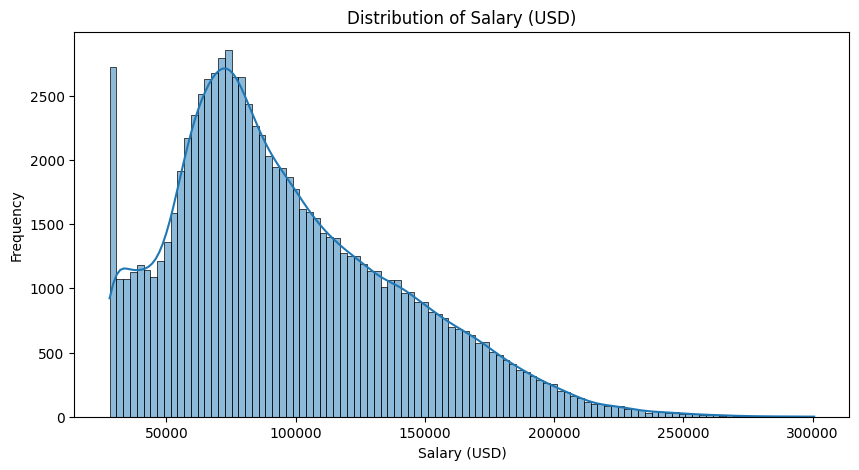

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(df["salary_usd"], kde=True)

plt.title("Distribution of Salary (USD)")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")

plt.show()

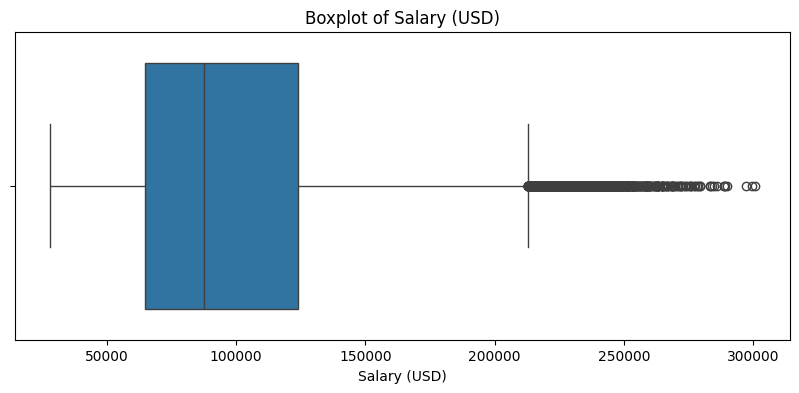

In [13]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["salary_usd"])

plt.title("Boxplot of Salary (USD)")
plt.xlabel("Salary (USD)")

plt.show()

### 5.2 Distribution of High-Cardinality Numerical Variables

To further examine the numerical features, the six numerical variables with the highest cardinality were selected, excluding `id`, which is only a record identifier, and `salary_usd`, which was analysed separately in Section 5.1.

The selected variables are `hiring_difficulty_score`, `bonus_usd`, `economic_index`, `offer_acceptance_rate`, `company_funding_billion`, and `layoff_risk`.

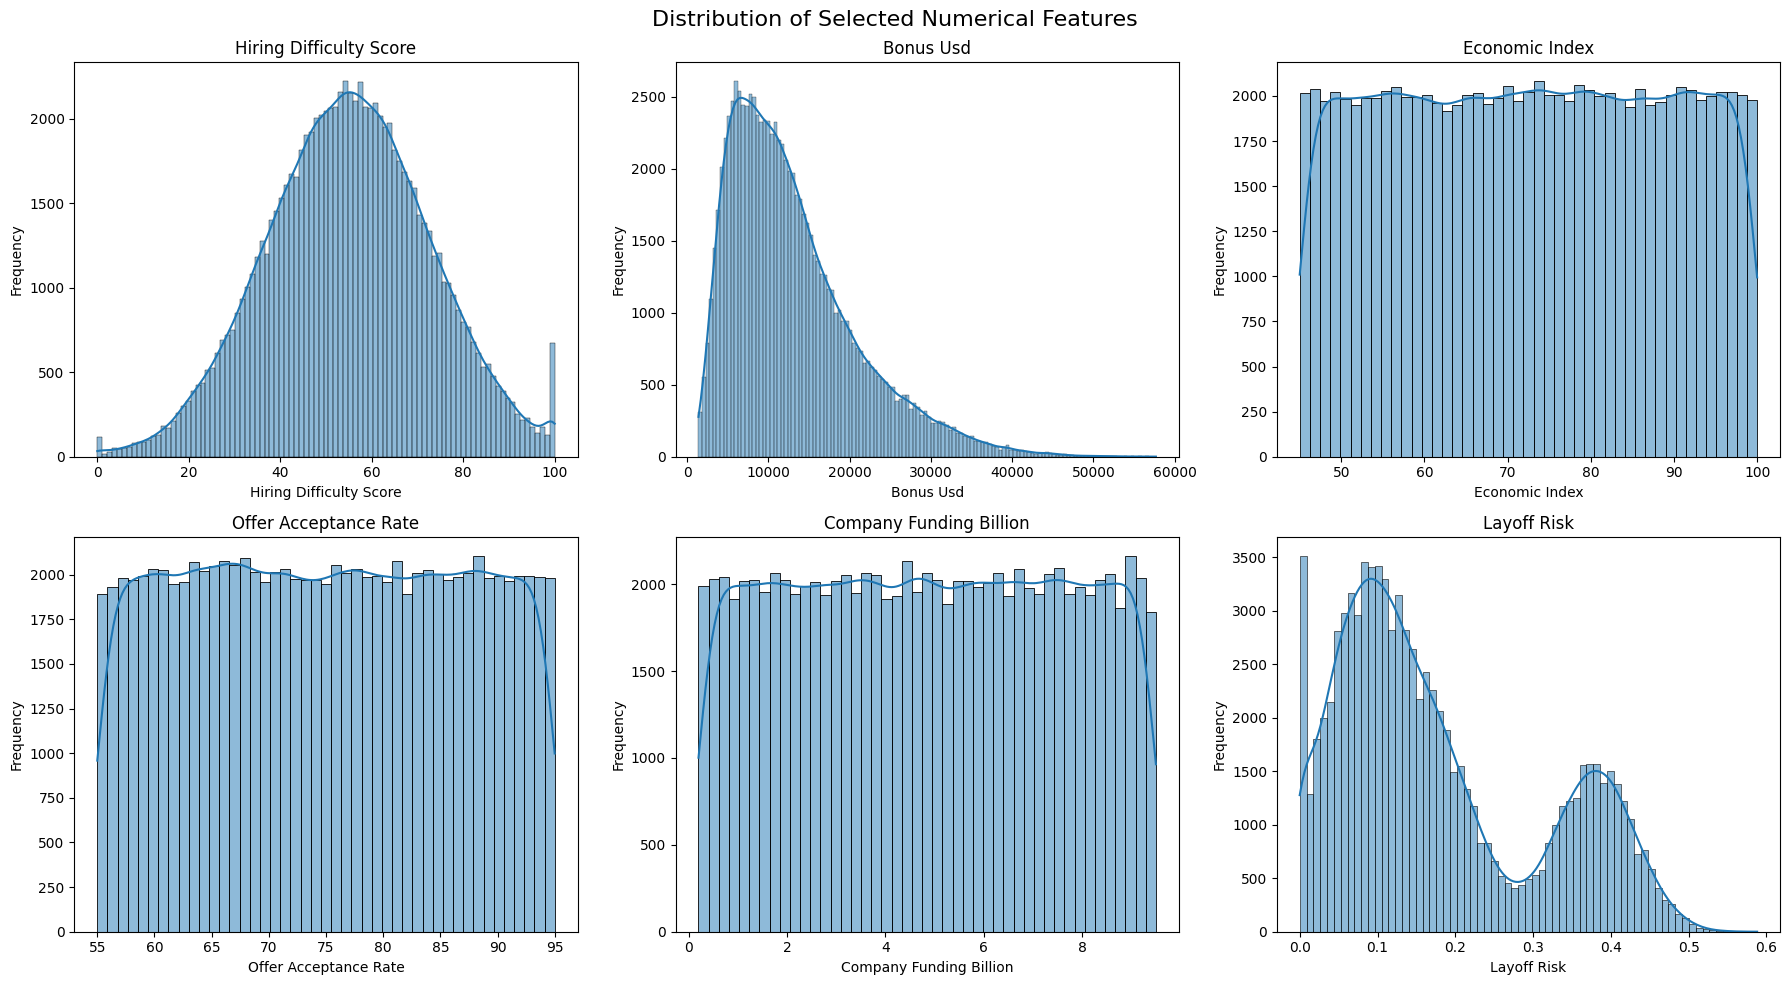

In [16]:
numerical_features = [
    "hiring_difficulty_score",   # 89,333 unique
    "bonus_usd",                 # 27,544 unique
    "economic_index",            # 5,501 unique
    "offer_acceptance_rate",     # 4,001 unique
    "company_funding_billion",   # 931 unique
    "layoff_risk"                # 549 unique
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, column in enumerate(numerical_features):
    sns.histplot(
        df[column],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(column.replace("_", " ").title())
    axes[i].set_xlabel(column.replace("_", " ").title())
    axes[i].set_ylabel("Frequency")

plt.suptitle("Distribution of Selected Numerical Features", fontsize=16)

plt.tight_layout()
plt.show()

The selected high-cardinality numerical variables show several different distribution patterns.

- `hiring_difficulty_score` is approximately bell-shaped, with most values concentrated around the middle of the scale. This suggests that moderate hiring difficulty is more common than extremely low or high difficulty.

- `bonus_usd` is strongly positively skewed. Most job records have relatively lower bonus values, while a smaller number of jobs offer much higher bonuses, resulting in a long right tail.

- `economic_index`, `offer_acceptance_rate`, and `company_funding_billion` are distributed relatively evenly across their observed ranges. This suggests that the dataset contains broad coverage of different economic conditions, acceptance rates, and company funding levels rather than being concentrated within a narrow range.

- `layoff_risk` shows a noticeably non-normal and approximately bimodal distribution, with one larger concentration at lower risk levels and another smaller concentration at higher risk levels. This may indicate the presence of different groups of jobs or companies with distinct layoff-risk characteristics.

Overall, the selected numerical variables do not follow a single common distribution. While several variables are relatively evenly distributed, `bonus_usd` is strongly right-skewed and `layoff_risk` shows two distinct peaks. This suggests that different numerical features may behave differently in relation to the target variable `salary_usd`.

### 5.3 Potential Outliers

Boxplots were examined for selected continuous numerical variables to identify observations that fall substantially outside the typical range.

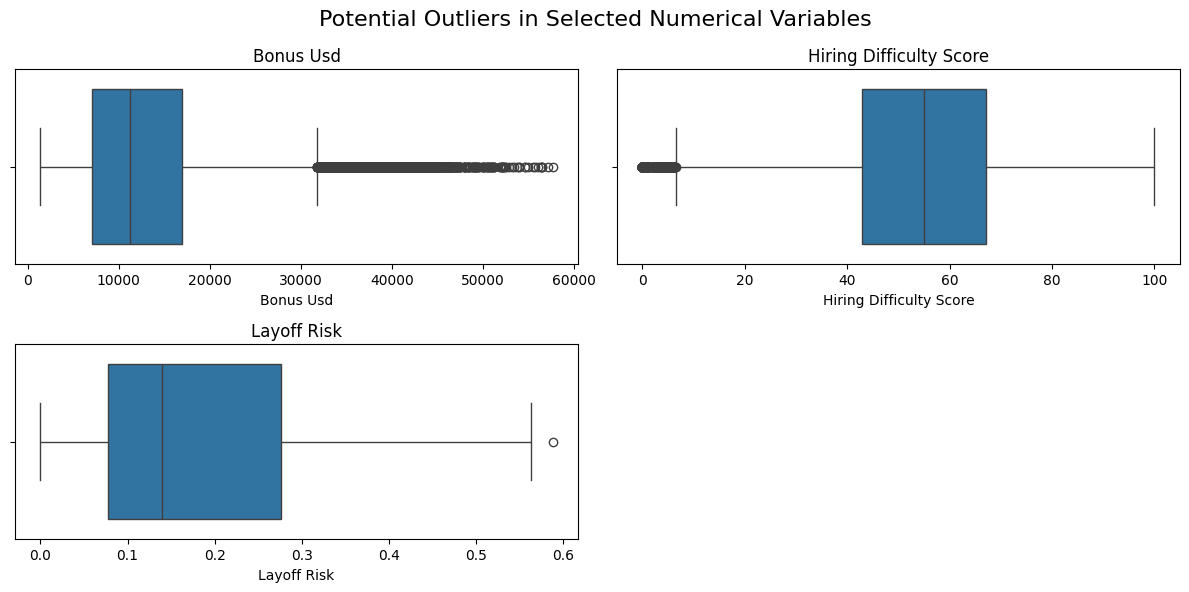

In [22]:
outlier_features = [
    "bonus_usd",
    "hiring_difficulty_score",
    "layoff_risk"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for i, column in enumerate(outlier_features):
    sns.boxplot(
        x=df[column],
        ax=axes[i]
    )

    axes[i].set_title(column.replace("_", " ").title())
    axes[i].set_xlabel(column.replace("_", " ").title())

axes[3].axis("off")
plt.suptitle("Potential Outliers in Selected Numerical Variables", fontsize=16)

plt.tight_layout()
plt.show()


Boxplots were used to identify potential outliers among selected numerical variables using the interquartile range (IQR).

- `bonus_usd` contains a large number of upper-end outliers, with values extending beyond approximately $32,000. This is consistent with its positively skewed distribution, where most jobs receive lower bonuses while a smaller number receive substantially higher bonuses.

- `hiring_difficulty_score` contains several potential outliers at the lower end of the scale. Most observations are concentrated around the middle range, while only a small number of records have extremely low hiring difficulty scores.

- `layoff_risk` contains very few potential outliers, with only an extreme value near the upper end being identified by the IQR rule.

These observations are not removed at this stage because statistical outliers identified by the IQR method do not necessarily represent invalid or anomalous data. As shown in the numerical range checks in Section 4.5, the values remain within reasonable and valid ranges for their respective variables, with no clearly impossible values identified. Therefore, the detected outliers are more likely to represent legitimate extreme observations, such as unusually high bonuses, very low hiring difficulty scores, or high layoff-risk values, rather than data-entry errors.

## 6. Bivariate Analysis

### 6.1 Correlation of Numerical Variables with Salary

The correlation between each numerical variable and the target variable `salary_usd` is examined to identify variables that have stronger linear relationships with salary.

In [23]:
numeric_df = df.select_dtypes(include=np.number).drop(columns=["id"])

salary_correlations = (
    numeric_df.corr()["salary_usd"]
    .drop("salary_usd")
    .sort_values(ascending=False)
)

salary_correlations

bonus_usd                  0.752046
experience_years           0.723879
employee_satisfaction      0.629030
job_security_score         0.434177
promotion_speed            0.261381
ai_adoption_score          0.006550
work_life_balance_score    0.003890
job_openings               0.003853
career_growth_score        0.003107
ai_maturity_years          0.002797
automation_risk            0.002201
cost_of_living_index       0.001462
skill_demand_score         0.001087
economic_index            -0.000094
offer_acceptance_rate     -0.000143
company_rating            -0.000347
company_funding_billion   -0.000362
hiring_difficulty_score   -0.000759
year                      -0.001309
tax_rate_percent          -0.003189
salary_percentile         -0.003327
weekly_hours              -0.004970
interview_rounds          -0.006230
vacation_days             -0.006457
layoff_risk               -0.533439
Name: salary_usd, dtype: float64

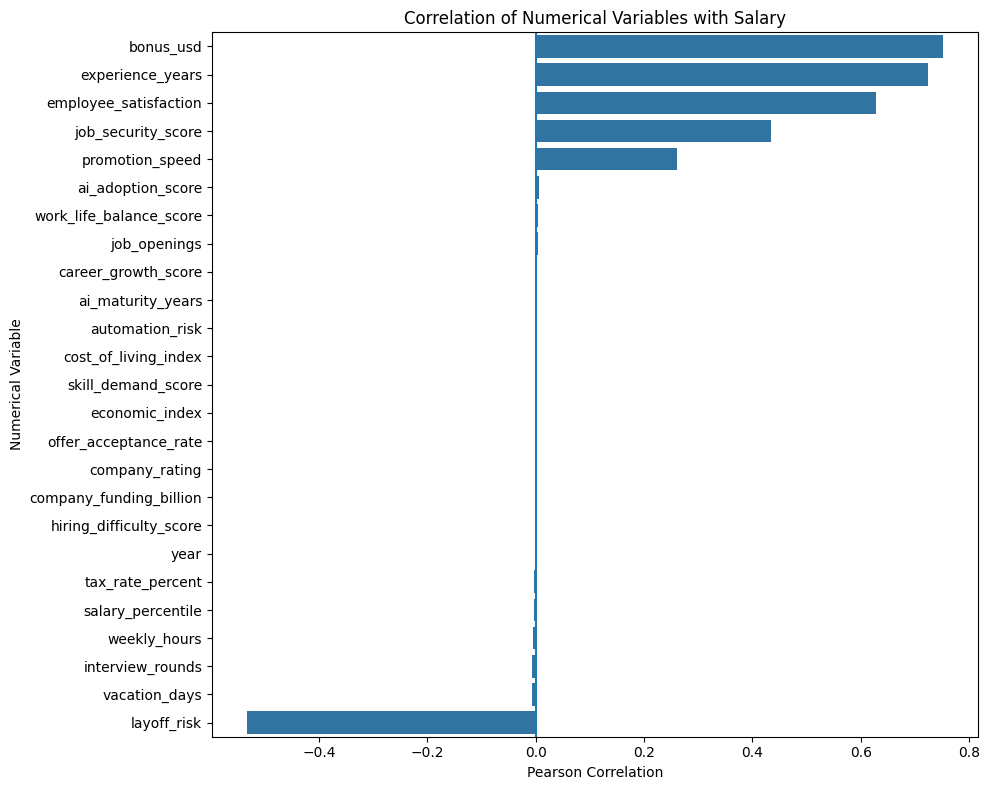

In [26]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x=salary_correlations.values,
    y=salary_correlations.index
)

plt.title("Correlation of Numerical Variables with Salary")
plt.xlabel("Pearson Correlation")
plt.ylabel("Numerical Variable")

plt.axvline(0)
plt.tight_layout()
plt.show()

Several variables show noticeable relationships with salary:

- `bonus_usd` has the strongest positive correlation with salary (**0.752**), indicating that jobs with higher base salaries also tend to provide higher bonuses.
- `experience_years` has a strong positive correlation (**0.724**), suggesting that salaries generally increase as the required level of professional experience increases.
- `employee_satisfaction` also has a moderately strong positive correlation (**0.629**) with salary.
- `job_security_score` has a moderate positive correlation (**0.434**), indicating that higher-paying jobs tend to be associated with greater job security.
- `promotion_speed` has a weaker positive correlation (**0.261**) with salary.

In contrast, `layoff_risk` has a moderately strong negative correlation of **-0.533**, indicating that higher salaries tend to be associated with lower layoff risk.

Most of the remaining numerical variables have correlations close to zero, suggesting little or no **linear relationship** with `salary_usd`. These include variables such as `economic_index`, `company_rating`, `weekly_hours`, `skill_demand_score`, and `salary_percentile`.

However, a low Pearson correlation does not necessarily mean that these variables have no relationship with salary. Some may have non-linear relationships or interact with other features, which would not be fully captured by Pearson correlation. Therefore, models that can capture non-linear relationships, such as tree-based models, may still find useful patterns in these variables, while a simple linear model may be less able to capture them without additional feature transformations or interaction terms.

### 6.2 Strong Relationships Between Numerical Variables

In [43]:
numeric_df = (
    df.select_dtypes(include=np.number)
    .drop(columns=["id"])
)

corr_matrix = numeric_df.corr()

# Keep only the upper triangle so pairs are not duplicated
upper_triangle = np.triu(
    np.ones(corr_matrix.shape),
    k=1
).astype(bool)

strong_correlations = (
    corr_matrix.where(upper_triangle)
    .stack()
    .reset_index()
)

strong_correlations.columns = [
    "Variable 1",
    "Variable 2",
    "Correlation"
]

# Keep correlations with absolute value >= 0.30
strong_correlations = strong_correlations[
    strong_correlations["Correlation"].abs() >= 0.30
]

strong_correlations = strong_correlations.sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

strong_correlations

,Variable 1,Variable 2,Correlation
130,weekly_hours,work_life_balance_score,-0.828129
198,layoff_risk,job_security_score,-0.814724
25,salary_usd,bonus_usd,0.752046
8,experience_years,layoff_risk,-0.736261
0,experience_years,salary_usd,0.723879
214,ai_adoption_score,career_growth_score,0.632821
48,salary_usd,employee_satisfaction,0.629030
228,company_funding_billion,career_growth_score,0.618247
18,experience_years,job_security_score,0.599466
1,experience_years,bonus_usd,0.545966


To identify notable relationships between numerical features, variable pairs with an absolute Pearson correlation of at least **0.30** were examined. This removes very weak correlations and makes the stronger relationships easier to interpret.

Several strong relationships were identified:

- `weekly_hours` and `work_life_balance_score` have the strongest negative correlation (**-0.828**), indicating that jobs with longer working hours tend to have lower work-life balance scores. The very strong relationship also suggests that these two variables may contain overlapping information where it is possible that work-life balance is partly influenced by weekly working hours.

- `layoff_risk` and `job_security_score` also have a very strong negative correlation (**-0.815**). This is logically consistent, as jobs with greater layoff risk tend to have lower job security. As both variables represent closely related employment-stability concepts, retaining both may introduce redundant information. This will be considered during feature selection.

- `experience_years` is positively correlated with `salary_usd` (**0.724**) and `job_security_score` (**0.599**), while being negatively correlated with `layoff_risk` (**-0.736**). This suggests that more experienced roles tend to be associated with higher salaries, greater job security and lower layoff risk.

- `salary_usd` and `bonus_usd` have a strong positive correlation (**0.752**), showing that higher-paying roles also tend to provide higher bonuses. Since bonus is another compensation-related variable, its availability and relationship with base salary should be examined before modelling. If `bonus_usd` is derived from or only known after determining salary, using it as a predictor could introduce target leakage.

- `employee_satisfaction` is positively related to `salary_usd` (**0.629**), `experience_years` (**0.517**) and `job_security_score` (**0.485**), while being negatively related to `layoff_risk` (**-0.459**). This suggests that higher satisfaction tends to occur alongside higher salaries, greater experience and stronger job security.

- `ai_adoption_score` and `career_growth_score` show a moderately strong positive correlation (**0.633**), while `company_funding_billion` and `career_growth_score` are also positively correlated (**0.618**). This suggests that stronger AI adoption and greater company funding may be associated with better perceived career growth opportunities.

Overall, the results show that several employment-related variables are interconnected rather than operating independently. In particular, experience, compensation, job security, layoff risk and employee satisfaction form a group of related characteristics. Strong correlations between predictors may indicate overlapping information or multicollinearity, which should be considered during feature selection and model development.

### 6.3 Relationship Between Selected Categorical Variables and Salary

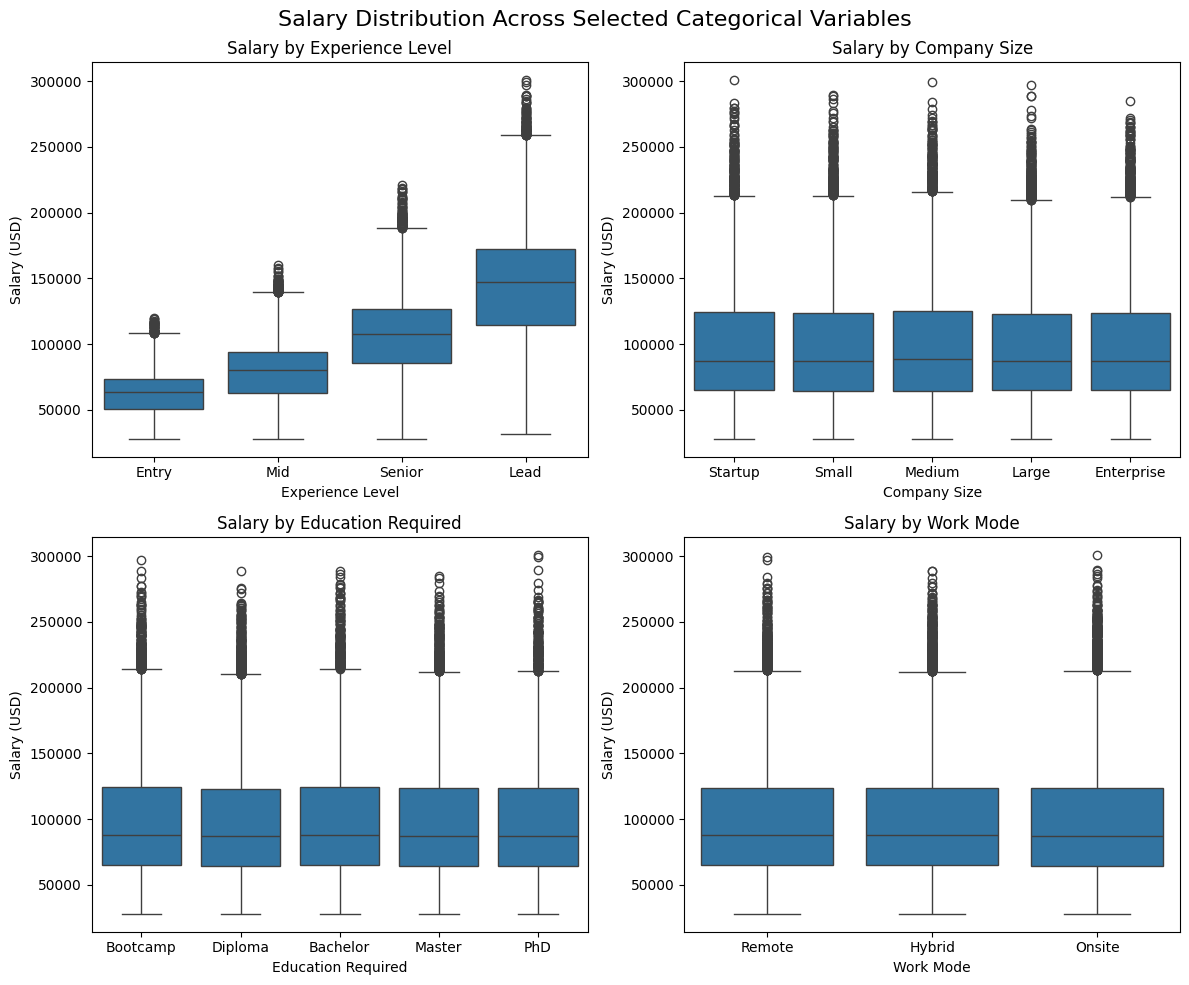

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Experience Level
sns.boxplot(
    data=df,
    x="experience_level",
    y="salary_usd",
    order=["Entry", "Mid", "Senior", "Lead"],
    ax=axes[0]
)
axes[0].set_title("Salary by Experience Level")
axes[0].set_xlabel("Experience Level")
axes[0].set_ylabel("Salary (USD)")

# Company Size
sns.boxplot(
    data=df,
    x="company_size",
    y="salary_usd",
    order=["Startup", "Small", "Medium", "Large", "Enterprise"],
    ax=axes[1]
)
axes[1].set_title("Salary by Company Size")
axes[1].set_xlabel("Company Size")
axes[1].set_ylabel("Salary (USD)")

# Education Required
sns.boxplot(
    data=df,
    x="education_required",
    y="salary_usd",
    order=["Bootcamp", "Diploma", "Bachelor", "Master", "PhD"],
    ax=axes[2]
)
axes[2].set_title("Salary by Education Required")
axes[2].set_xlabel("Education Required")
axes[2].set_ylabel("Salary (USD)")

# Work Mode
sns.boxplot(
    data=df,
    x="work_mode",
    y="salary_usd",
    order=["Remote", "Hybrid", "Onsite"],
    ax=axes[3]
)
axes[3].set_title("Salary by Work Mode")
axes[3].set_xlabel("Work Mode")
axes[3].set_ylabel("Salary (USD)")

plt.suptitle(
    "Salary Distribution Across Selected Categorical Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()

The boxplots show that `experience_level` has a much clearer relationship with `salary_usd` than the other selected categorical variables.

- `experience_level` shows a clear upward trend in salary. Entry-level roles have the lowest median salary, followed by Mid, Senior, and Lead roles. The salary range also becomes wider at higher experience levels, especially for Lead roles. This suggests that experience level is an important factor associated with salary.

- `company_size` shows very similar salary distributions across Startup, Small, Medium, Large, and Enterprise companies. The medians and interquartile ranges are nearly identical, suggesting that company size has little standalone relationship with salary.

- `education_required` also shows highly similar salary distributions across Bootcamp, Diploma, Bachelor, Master, and PhD categories. This suggests that the required education qualification alone does not strongly differentiate salary in this dataset.

- `work_mode` shows almost identical salary distributions across Remote, Hybrid, and Onsite roles. This indicates that work arrangement does not appear to have a strong standalone relationship with salary.

Overall, `experience_level` shows the strongest categorical relationship with salary among the variables examined, while `company_size`, `education_required`, and `work_mode` show little separation in their salary distributions.

### 6.4 Median Salary Across High-Cardinality Categorical Variables

The median salary is compared across categorical variables with a larger number of categories. Median salary is used because `salary_usd` is positively skewed and contains high-value observations, making the median less sensitive to extreme salaries than the mean.

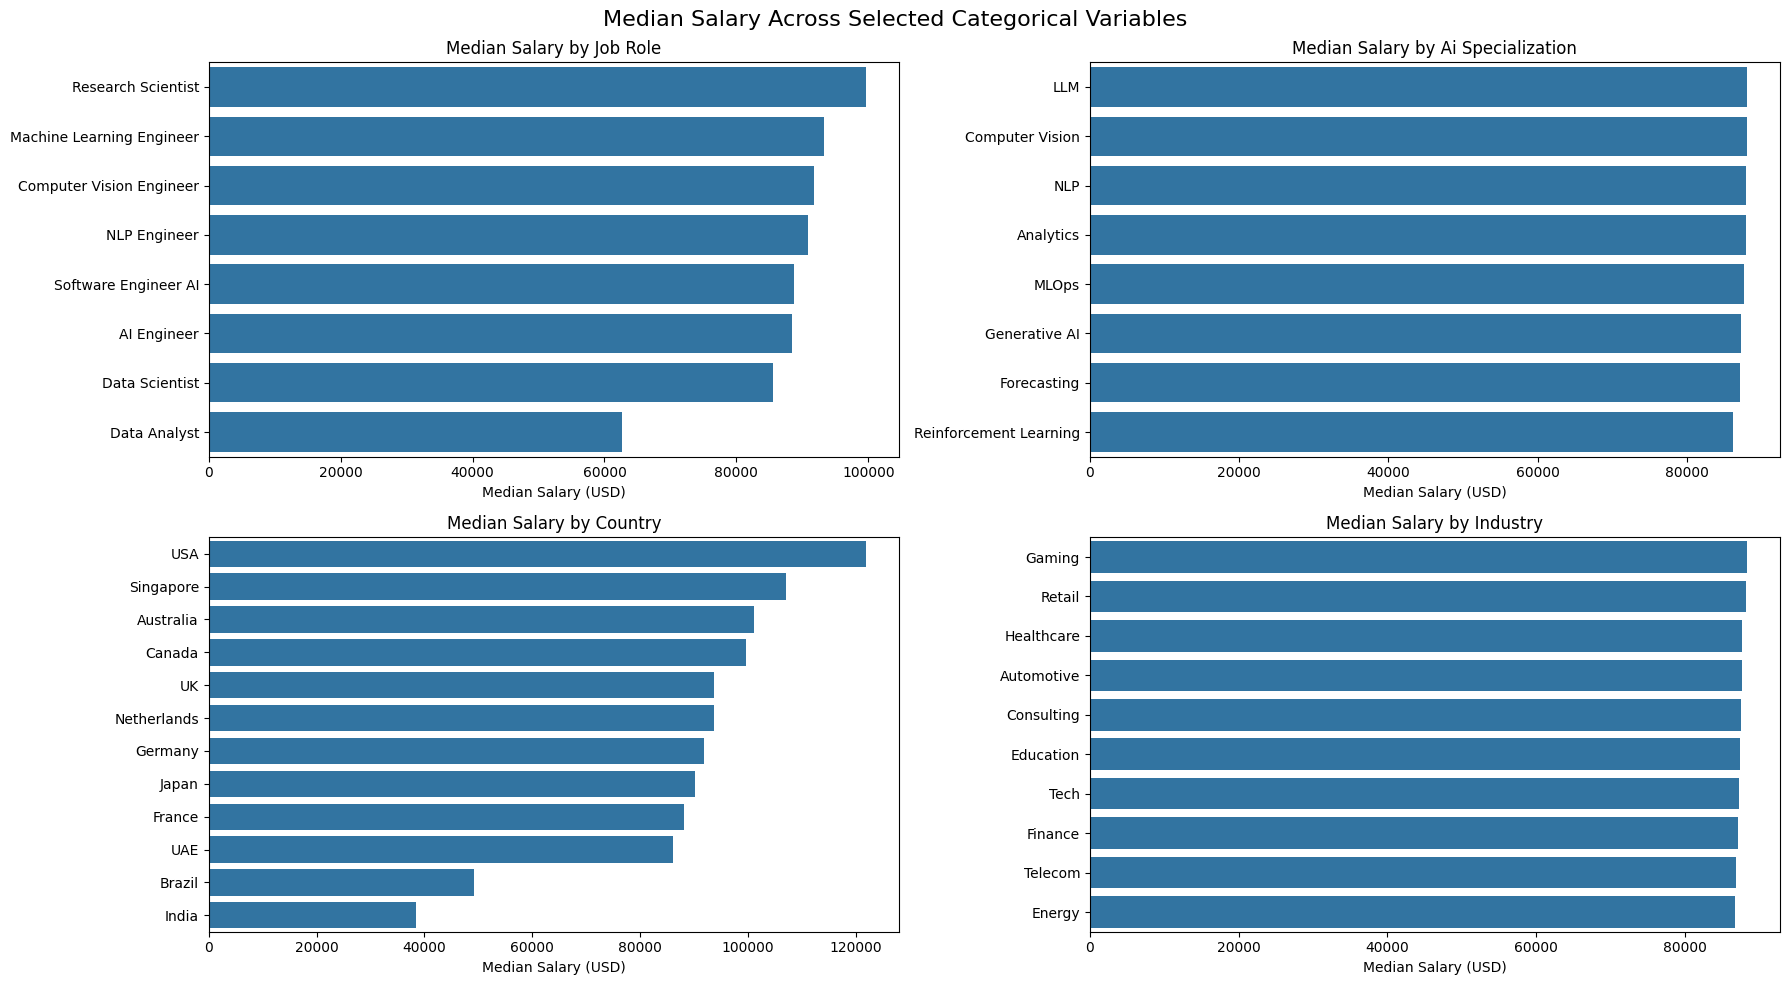

In [38]:
categorical_features = [
    "job_role",
    "ai_specialization",
    "country",
    "industry"
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, column in enumerate(categorical_features):

    median_salary = (
        df.groupby(column)["salary_usd"]
        .median()
        .sort_values(ascending=False)
    )

    sns.barplot(
        x=median_salary.values,
        y=median_salary.index,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Median Salary by {column.replace('_', ' ').title()}"
    )

    axes[i].set_xlabel("Median Salary (USD)")
    axes[i].set_ylabel("")

plt.suptitle(
    "Median Salary Across Selected Categorical Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()

The median salary comparison shows that `job_role` and `country` have much clearer differences in salary than `ai_specialization` and `industry`.

- `job_role` shows substantial variation in median salary. `Research Scientist` has the highest median salary at approximately **$100,000**, while `Data Analyst` has the lowest at approximately **$63,000**. Other technical roles such as Machine Learning Engineer, Computer Vision Engineer, and NLP Engineer also have relatively high median salaries. This suggests that job role is an important factor associated with salary.

- `country` shows the largest differences among the categorical variables examined. The USA has the highest median salary at approximately **$120,000**, followed by Singapore at above **$100,000**, while India and Brazil have considerably lower median salaries. This suggests that geographical location is strongly associated with salary levels in the dataset.

- `ai_specialization` shows very little variation in median salary across specialisations. Although LLM-related roles have the highest median salary, the differences between specialisations are relatively small, suggesting that AI specialisation alone does not strongly differentiate salary.

- `industry` also shows very similar median salaries across all sectors. The small differences between industries suggest that industry has relatively little standalone association with salary in this dataset.

Overall, `country` and `job_role` appear to provide considerably more separation in salary than `ai_specialization` and `industry`.

## 7. Multivariate Analysis

### 7.1 Median Salary by Experience Level and Country

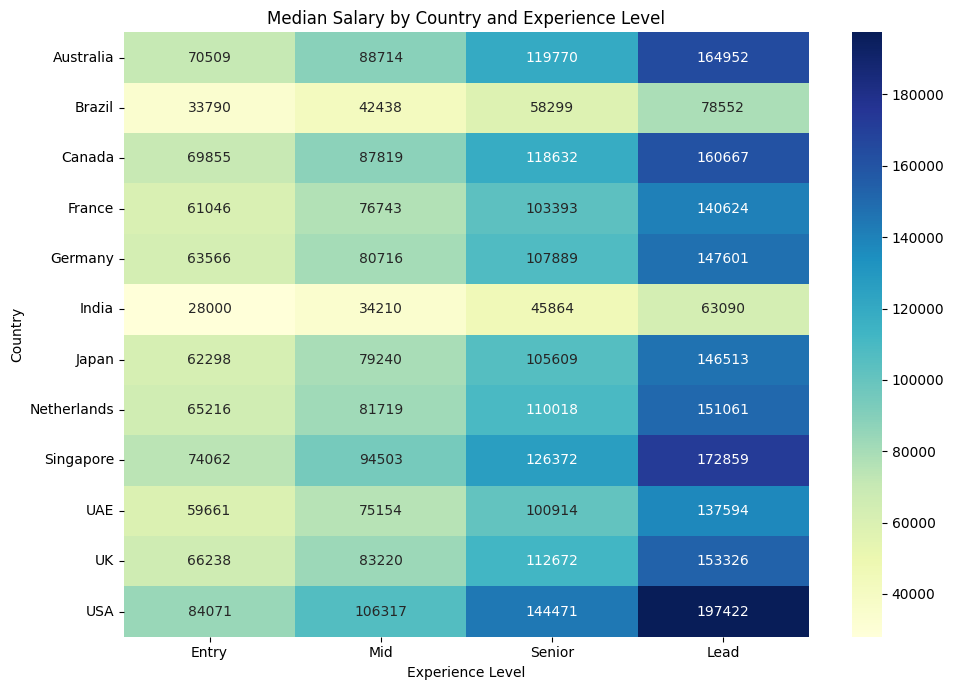

In [39]:
salary_pivot = df.pivot_table(
    values="salary_usd",
    index="country",
    columns="experience_level",
    aggfunc="median"
)

salary_pivot = salary_pivot[
    ["Entry", "Mid", "Senior", "Lead"]
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    salary_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Median Salary by Country and Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

The heatmap shows that both `country` and `experience_level` are associated with differences in median salary.

Across every country, median salary increases consistently from `Entry` to `Mid`, `Senior`, and `Lead` level. This confirms that experience level has a strong relationship with salary regardless of geographical location.

At the same experience level, salary also varies noticeably across countries. For example, the USA has the highest median salary across all four experience levels, while India and Brazil have the lowest. Singapore and Australia also show relatively high median salaries compared with many other countries.

The combination of country and experience level therefore provides more information than examining either variable alone. For example, a Lead-level role in the USA has a median salary of around **$197,422**, compared with **$63,090** for a Lead-level role in India.

### 7.2 Median Salary by Job Role and Experience Level

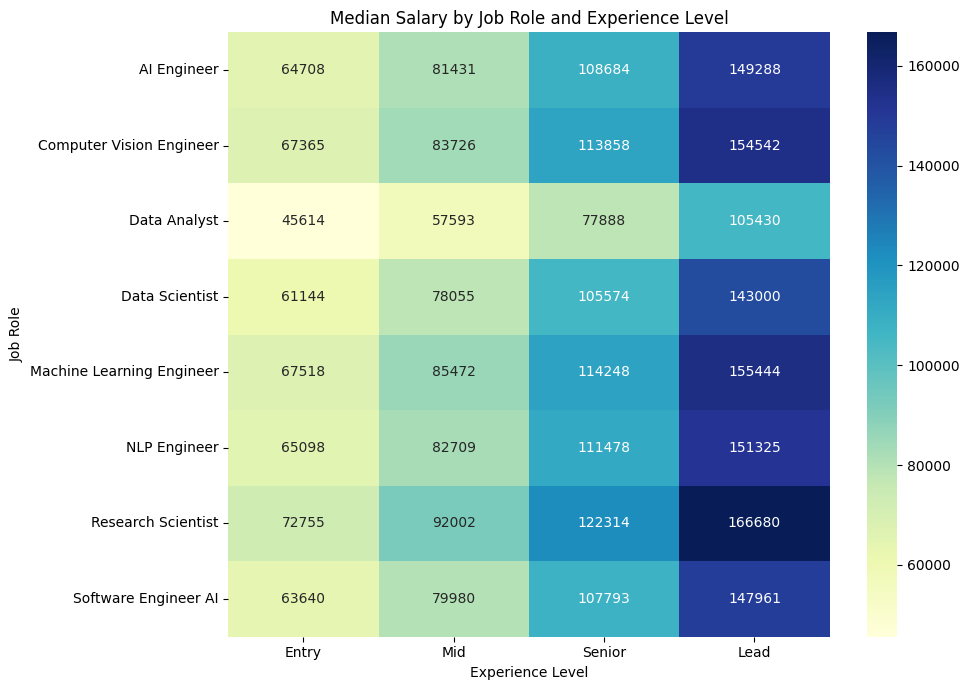

In [40]:
role_experience_salary = df.pivot_table(
    values="salary_usd",
    index="job_role",
    columns="experience_level",
    aggfunc="median"
)

role_experience_salary = role_experience_salary[
    ["Entry", "Mid", "Senior", "Lead"]
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    role_experience_salary,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Median Salary by Job Role and Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()

The heatmap shows clear differences in median salary across both `job_role` and `experience_level`.

Across every job role, median salary increases consistently from `Entry` to `Mid`, `Senior`, and `Lead`, reinforcing the strong relationship between experience level and salary identified earlier.

Differences are also observed between job roles at the same experience level. `Research Scientist` has the highest median salary across all four experience levels, ranging from approximately **$72,755** at Entry level to **$166,680** at Lead level. In contrast, `Data Analyst` consistently has the lowest median salary, ranging from approximately **$45,614** at Entry level to **$105,430** at Lead level.

Roles such as `Machine Learning Engineer` and `Computer Vision Engineer` also have relatively high median salaries across experience levels.

The salary differences between job roles also appear to become larger at higher experience levels. For example, the difference between Research Scientist and Data Analyst is approximately **$27,000** at Entry level but increases to more than **$61,000** at Lead level.

Overall, the results indicate that both job role and experience level are important factors associated with salary, and considering them together provides a more detailed view of salary differences than analysing either variable independently.

### 7.3 Median Salary Trend by Year and Experience Level

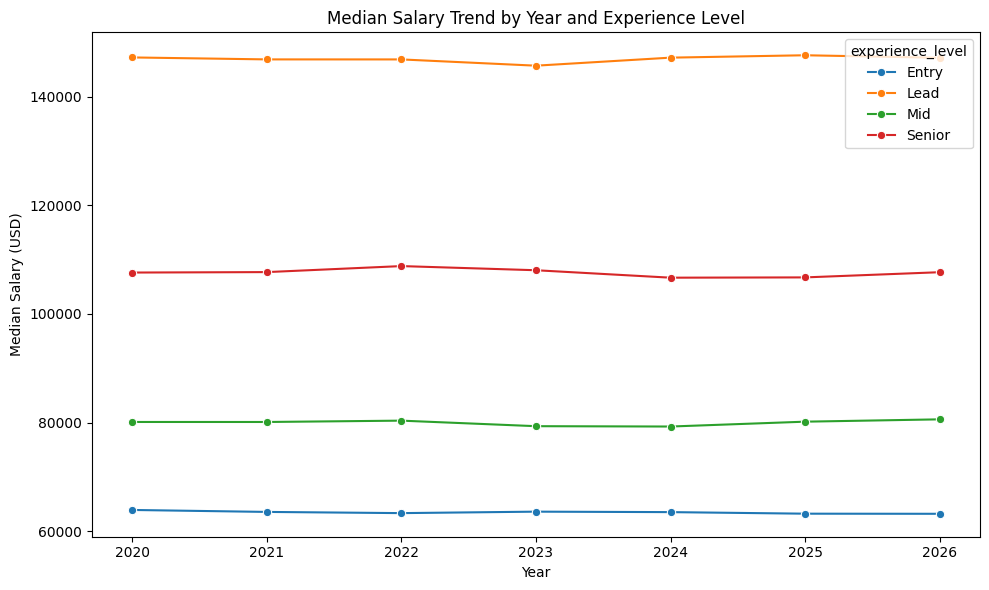

In [51]:
salary_by_year_exp = (
    df.groupby(["year", "experience_level"])["salary_usd"]
    .median()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=salary_by_year_exp,
    x="year",
    y="salary_usd",
    hue="experience_level",
    marker="o"
)

plt.title("Median Salary Trend by Year and Experience Level")
plt.xlabel("Year")
plt.ylabel("Median Salary (USD)")

plt.tight_layout()
plt.show()

Median salary differs substantially across experience levels, with Lead and Senior roles consistently earning more than Mid and Entry roles.

However, within each experience level, median salaries remain relatively stable from 2020 to 2026. For example, Lead-level median salary remains around $147,000 throughout the period, while Entry-level salary remains around $63,000-$64,000.

This suggests that `experience_level` has a much stronger relationship with salary than `year`. There is little evidence of a strong overall salary trend over time in this dataset.

## 8. Key EDA Findings

The exploratory analysis identified several important patterns relevant to the salary prediction task:

- `salary_usd` is positively skewed and contains legitimate high-salary observations rather than clearly invalid values.
- `bonus_usd` is strongly right-skewed, while `layoff_risk` displays a more complex bimodal distribution.
- Numerical variables most strongly associated with salary include `bonus_usd`, `experience_years`, `employee_satisfaction`, `layoff_risk`, and `job_security_score`.
- Several predictors are strongly related to one another, including `weekly_hours` with `work_life_balance_score` and `layoff_risk` with `job_security_score`, indicating possible redundant information or multicollinearity.
- `experience_level`, `job_role`, and `country` show clear differences in salary, while `company_size`, `education_required`, `work_mode`, `ai_specialization`, and `industry` show considerably smaller standalone differences.
- Multivariate analysis shows that salary increases consistently with experience level across both countries and job roles, while the absolute salary level also varies substantially between countries and roles.
- Potential leakage-prone or redundant variables, such as `bonus_usd`, will be dealt with during preprocessing and model development.
- Median salaries remain relatively stable from 2020 to 2026 within each experience level, suggesting that `experience_level` has a much stronger relationship with salary than `year`.